# Module 1.8 — 1D Burgers' Equation

**The equation that connects everything:**
$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}$$

Burgers' equation is the 1D prototype of the Navier-Stokes equations. It contains:
- $u \partial_x u$ — the nonlinear convective term (same form as in N-S)
- $\nu \partial_{xx} u$ — viscous diffusion (same form as in N-S)

Everything you learn in this module carries over directly to the full N-S equations in Module 2.

**Roadmap:**
1. Physical intuition — the traffic jam mechanism of shock formation
2. Conservative vs. non-conservative form — why it matters for shocks
3. Characteristics — how information propagates in nonlinear equations
4. Inviscid case ($\nu=0$): shock formation and the Rankine-Hugoniot condition
5. Viscous case ($\nu>0$): the shock structure and the Reynolds number analogy
6. Implementation: explicit scheme with shock capturing
7. Connection to Navier-Stokes

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Traffic Jam Analogy

### Why nonlinearity causes shocks

In linear advection (Module 1.6), every part of the initial profile moves at the same speed $c$. The shape is preserved.

In Burgers' equation, each part of the profile moves at **its own speed** — the local value of $u$. A region where $u = 2$ moves twice as fast as a region where $u = 1$.

Imagine cars on a highway:
```
Fast cars  →→→→→→→→→→→→  Slow cars ahead
                         ↓
Fast cars catch up → PILE-UP = SHOCK
```

In fluid terms: the high-velocity region of the initial wave catches up to the low-velocity region ahead of it. The wave steepens until it becomes a vertical front — a **shock**.

### Shock formation time

For the inviscid equation, the characteristics are lines $x(t) = x_0 + u_0(x_0)\,t$. Two characteristics starting at $x_0$ and $x_0 + \delta x$ meet at time:

$$t_s = -\frac{1}{\min(\partial u_0/\partial x)}$$

If the initial profile has a negative slope anywhere ($u_0' < 0$), a shock forms in finite time. The shock formation time is determined by the steepest downslope in the initial condition.

For $u_0 = \sin(x)$: $\min(u_0') = -1$ at $x=\pi$, so $t_s = 1$.

## 2. Conservative vs. Non-Conservative Form

### Two ways to write the same equation

**Non-conservative (advective) form:**
$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = 0$$

**Conservative (divergence) form:**
$$\frac{\partial u}{\partial t} + \frac{\partial}{\partial x}\left(\frac{u^2}{2}\right) = 0$$

For smooth solutions, these are equivalent (product rule: $\partial(u^2/2)/\partial x = u \partial u/\partial x$).

### Why it matters at shocks

At a shock, $u$ is discontinuous. The derivative $\partial u/\partial x$ does not exist in the classical sense — you cannot compute $u \cdot \partial u/\partial x$ point-by-point.

The conservative form avoids this: $\partial(u^2/2)/\partial x$ can be interpreted in the **weak (integral) sense** even when $u$ is discontinuous. The correct shock speed (Rankine-Hugoniot condition) is obtained only from the conservative form:

$$s = \frac{u_L + u_R}{2} \quad \text{(shock speed for Burgers' equation)}$$

where $u_L$ and $u_R$ are the values on the left and right of the shock.

**Rule: always discretise the convective term in conservation form.** Non-conservative schemes give the wrong shock speed.

This rule applies directly to the Navier-Stokes equations: the momentum equation must be in conservative form ($\nabla\cdot(\rho\mathbf{u}\mathbf{u})$, not $\rho(\mathbf{u}\cdot\nabla)\mathbf{u}$) for correct shock-capturing in compressible flow.

## 3. The Viscous Burgers Equation and the Reynolds Number Analogy

### What viscosity does to a shock

Adding viscosity ($\nu > 0$) regularises the shock: instead of a discontinuity, there is a **thin smooth transition layer**. The thickness of this layer scales as:

$$\delta \sim \frac{\nu}{\Delta U}$$

where $\Delta U = u_L - u_R$ is the velocity jump across the shock.

The ratio of the shock amplitude to the viscous thickness defines a **shock Reynolds number**:

$$Re_{\text{shock}} = \frac{\Delta U \cdot \delta}{\nu} \sim 1$$

At the shock, inertia and viscosity are exactly balanced — this is the same balance that defines the thickness of a laminar boundary layer. The analogy with the N-S Reynolds number is not a coincidence — Burgers' equation is the N-S equations reduced to 1D.

### The exact solution for any $\nu > 0$

The **Cole-Hopf transformation** $u = -2\nu (\partial_x \phi)/\phi$ converts Burgers' to the linear heat equation. The exact solution for sinusoidal IC is:

$$u(x,t) = \frac{\sum_n (-1)^{n+1} 2n\,e^{-n^2\pi^2\nu t}\sin(n\pi x)}{\sum_n e^{-n^2\pi^2\nu t}\cos(n\pi x)}$$

At small $\nu$: the solution develops a sharp internal layer (shock). At large $\nu$: viscosity smooths everything quickly and the solution decays like a heat equation.

/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_13066/1052683741.py:31: RuntimeWarning: overflow encountered in multiply
  F_right = 0.5*(F[1:] + F[:-1]) - 0.5*(dx/dt)*speed*(un[1:] - un[:-1])
/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_13066/1052683741.py:34: RuntimeWarning: invalid value encountered in subtract
  u[1:-1] = un[1:-1] - dt/dx*(F_right[1:] - F_right[:-1])


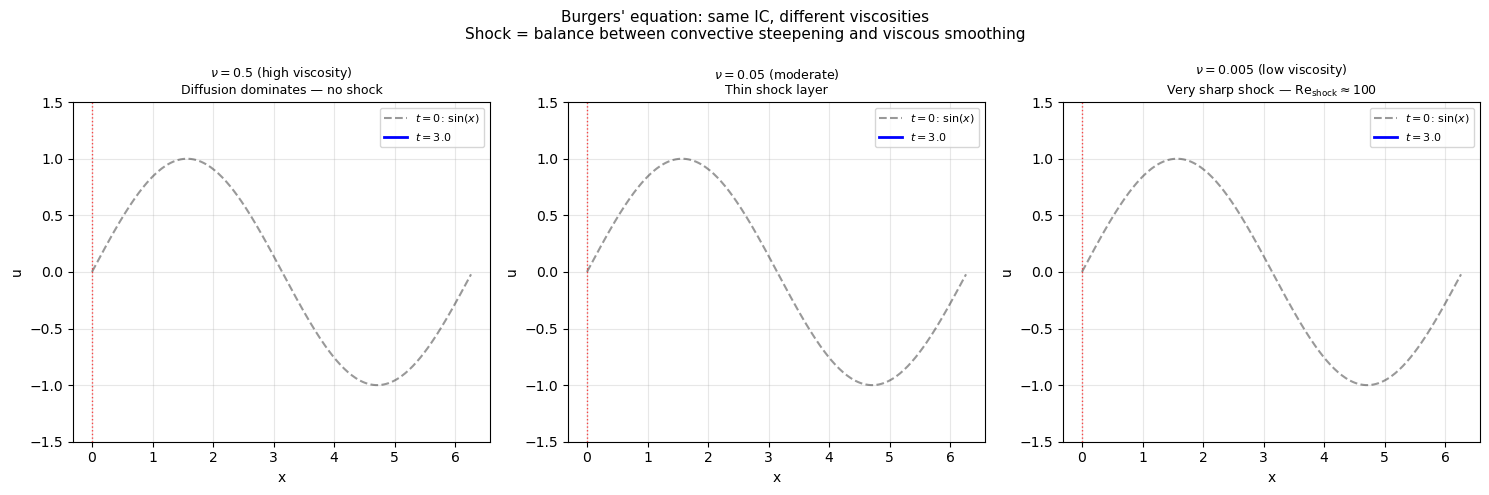


Viscosity is the Reynolds number dial:
  ν= 0.500  →  Re_shock ~ 2  →   diffusion dominates
  ν= 0.050  →  Re_shock ~ 20  →   sharp shock
  ν= 0.005  →  Re_shock ~ 200  →   sharp shock


In [2]:
# ── Burgers' equation solver ─────────────────────────────────────────────────
# Conservative form: ∂u/∂t + ∂(u²/2)/∂x = ν∂²u/∂x²
# Lax-Friedrichs for convective flux (conservative, handles shocks)
# Explicit central for diffusion

def burgers_solve(u0, nu, dx, T, cfl_convection=0.4, cfl_diffusion=0.4):
    """
    Solve viscous Burgers' equation using conservative Lax-Friedrichs flux.
    Time step chosen to satisfy both CFL conditions.
    """
    u = u0.copy()
    N = len(u)
    t = 0.0

    while t < T:
        umax = np.max(np.abs(u)) + 1e-10
        # CFL for convection: dt < dx / max|u|
        dt_conv = cfl_convection * dx / umax
        # Stability for diffusion: dt < dx² / (2ν)
        dt_diff = cfl_diffusion * dx**2 / (2*nu + 1e-12)
        dt = min(dt_conv, dt_diff, T - t)

        un = u.copy()

        # ── Conservative Lax-Friedrichs flux at faces ───────────────────────
        # F(u) = u²/2
        F       = 0.5 * un**2
        # Lax-Friedrichs: F_{i+1/2} = (F_i + F_{i+1})/2 - (dx/2dt)*(u_{i+1}-u_i)
        # The dissipation term makes the scheme conservative AND stable
        speed   = umax                      # max wave speed for diffusion
        F_right = 0.5*(F[1:] + F[:-1]) - 0.5*(dx/dt)*speed*(un[1:] - un[:-1])

        # ── Update interior from flux balance ───────────────────────────────
        u[1:-1] = un[1:-1] - dt/dx*(F_right[1:] - F_right[:-1])

        # ── Diffusion (explicit, central) ────────────────────────────────────
        u[1:-1] += dt * nu * (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2

        # ── BCs: periodic ────────────────────────────────────────────────────
        u[0] = u[-2];  u[-1] = u[1]

        t += dt
    return u

# ── Setup: sine wave IC on [0, 2π] ───────────────────────────────────────────
N  = 300
L  = 2 * np.pi
dx = L / N
x  = np.linspace(0, L, N, endpoint=False)
u0 = np.sin(x)

# Shock formation time for u0=sin(x): t_s = 1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

viscosities = [0.5, 0.05, 0.005]
titles = [
    '$\\nu = 0.5$ (high viscosity)\nDiffusion dominates — no shock',
    '$\\nu = 0.05$ (moderate)\nThin shock layer',
    '$\\nu = 0.005$ (low viscosity)\nVery sharp shock — Re$_{\\mathrm{shock}} \\approx 100$'
]

for ax, nu, title in zip(axes, viscosities, titles):
    T_final = 3.0
    u_final = burgers_solve(u0, nu, dx, T_final)

    ax.plot(x, u0,      'k--', lw=1.5, alpha=0.4, label='$t=0$: $\\sin(x)$')
    ax.plot(x, u_final, 'b-',  lw=2,              label=f'$t={T_final}$')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.5, 1.5)

    # Mark approximate shock location and width
    grad = np.gradient(u_final, dx)
    i_shock = np.argmin(grad)
    ax.axvline(x[i_shock], color='r', lw=1, linestyle=':', alpha=0.7)

plt.suptitle("Burgers' equation: same IC, different viscosities\n"
             'Shock = balance between convective steepening and viscous smoothing', fontsize=11)
plt.tight_layout()
plt.show()

print('\nViscosity is the Reynolds number dial:')
for nu in viscosities:
    Re_shock = 1.0 / (nu + 1e-10)   # ΔU ~ 1, δ ~ ν
    print(f'  ν={nu:6.3f}  →  Re_shock ~ {Re_shock:.0f}  →  ',
          'diffusion dominates' if nu >= 0.1 else 'sharp shock')

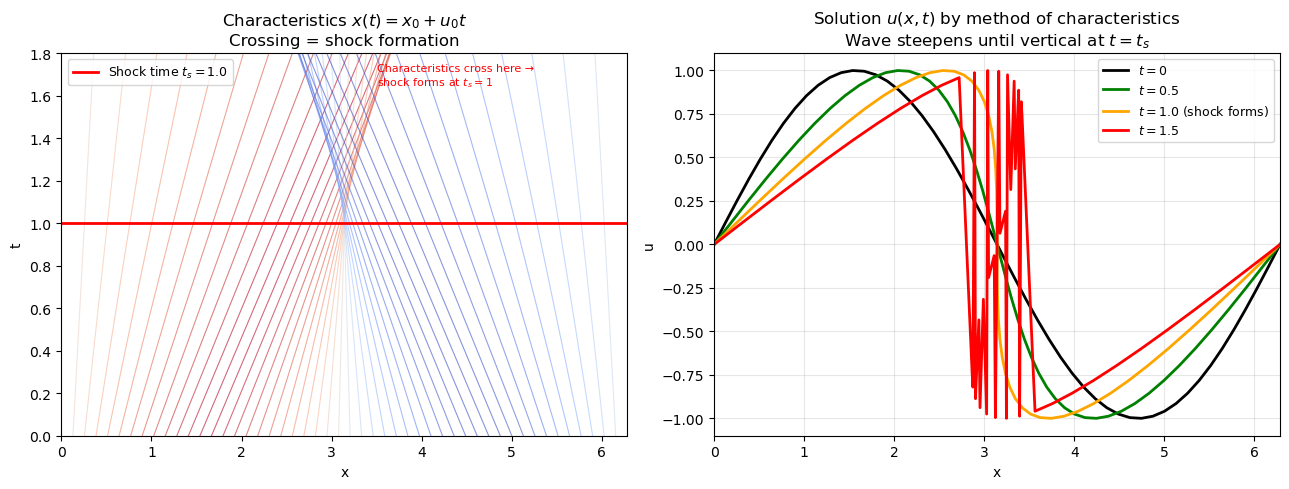

After t = t_s = 1.0:
  Inviscid: solution is multi-valued (physically inadmissible)
  Viscous:  thin shock layer resolves the crossing — unique single-valued solution
  Numerical: upwind scheme smears the shock over ~5-10 cells


In [3]:
# ── Characteristics: visualise shock formation from first principles ─────────
# x(t) = x₀ + u₀(x₀)·t — characteristic lines cross at t = t_shock

x0_vals = np.linspace(0, 2*np.pi, 50)
u0_vals = np.sin(x0_vals)
t_shock = 1.0   # for u0=sin(x): -1/min(u0') = -1/(-1) = 1

t_range = np.linspace(0, 1.8, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: characteristic lines in (x, t) space
for x0, u0 in zip(x0_vals, u0_vals):
    x_char = x0 + u0 * t_range
    color = plt.cm.coolwarm(0.5 + 0.5*u0)  # colour by initial velocity
    axes[0].plot(x_char, t_range, '-', color=color, lw=0.8, alpha=0.6)

axes[0].axhline(t_shock, color='red', lw=2, label=f'Shock time $t_s = {t_shock}$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
axes[0].set_title('Characteristics $x(t) = x_0 + u_0 t$\n'
                   'Crossing = shock formation')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 2*np.pi); axes[0].set_ylim(0, 1.8)
axes[0].text(3.5, 1.65, 'Characteristics cross here →\nshock forms at $t_s=1$',
             fontsize=8, color='red')

# Right: solution profiles at different times
times = [0, 0.5, 1.0, 1.5]
colors_t = ['black', 'green', 'orange', 'red']
for t_plot, color in zip(times, colors_t):
    # Method of characteristics (valid for t < t_shock)
    x_char = x0_vals + u0_vals * t_plot
    idx    = np.argsort(x_char)
    label  = f'$t={t_plot}$' + (' (shock forms)' if t_plot == 1.0 else '')
    axes[1].plot(x_char[idx], u0_vals[idx], '-', color=color, lw=2, label=label)

axes[1].set_xlabel('x'); axes[1].set_ylabel('u')
axes[1].set_title('Solution $u(x,t)$ by method of characteristics\n'
                   'Wave steepens until vertical at $t=t_s$')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 2*np.pi)

plt.tight_layout()
plt.show()

print('After t = t_s = 1.0:')
print('  Inviscid: solution is multi-valued (physically inadmissible)')
print('  Viscous:  thin shock layer resolves the crossing — unique single-valued solution')
print('  Numerical: upwind scheme smears the shock over ~5-10 cells')

## 4. Connection to Navier-Stokes — Why You Studied Burgers' Equation

| Burgers' property | Navier-Stokes equivalent |
|------------------|--------------------------|
| $u\partial_x u$ (nonlinear advection) | $(\mathbf{u}\cdot\nabla)\mathbf{u}$ (convective inertia) |
| $\nu\partial_{xx}u$ (viscous diffusion) | $\nu\nabla^2\mathbf{u}$ (viscous stress) |
| Reynolds number $1/\nu$ | Flow Reynolds number $UL/\nu$ |
| Shock = thin internal layer | Boundary layer = thin wall-attached layer |
| Conservative form required | Conservative N-S form required |
| CFL for convection + $r$ for diffusion | Same two constraints in 2D N-S |

Every numerical difficulty you encountered in Burgers' — stability, shock smearing, time-step restrictions — appears again in the Navier-Stokes solver. The solutions are the same: upwind for convection, implicit for diffusion, conservative discretisation.

## Summary

| Concept | Key point |
|---------|----------|
| Nonlinearity | $u\partial_x u$: each part of the wave moves at its own speed |
| Shock formation | Occurs in finite time $t_s = -1/\min(u_0')$ for smooth IC |
| Conservative form | Required for correct shock speed (Rankine-Hugoniot) |
| Viscosity | Regularises shock into a layer of thickness $\sim \nu/\Delta U$ |
| Time step | Must satisfy **both** $\Delta t \leq \Delta x/|u|$ (CFL) AND $\Delta t \leq \Delta x^2/(2\nu)$ |
| Connection to N-S | Burgers is the 1D N-S; all its difficulties carry over to 2D |

---
**End of Module 1.** You have built every scalar PDE solver you need for what comes next.

**Next:** Module 2.1 — 2D Scalar Transport: extending to two spatial dimensions, structured grids, and the operator-splitting approach.

## Exercise

**Predict first, then verify.**

1. For the initial condition $u_0(x) = 1 - x/2$ on $[0, 2]$ (a negative slope everywhere): predict $t_s$ from the formula $t_s = -1/\min(u_0')$. Run the inviscid solver and confirm the shock appears at that time.

2. The Rankine-Hugoniot condition for Burgers' equation says the shock speed is $s = (u_L + u_R)/2$ where $u_L$ and $u_R$ are the values on either side. For the sine-wave IC at $t > t_s$: does the shock in your simulation move at the predicted speed?

3. **Numerical diffusion effect:** Run the same case with $\nu = 0$ (inviscid) using three different grid resolutions ($N = 50, 100, 200$). Does the shock become sharper with finer grid? Measure the shock thickness (width of the transition layer) as a function of $N$. What does this tell you about the numerical diffusion coefficient of the Lax-Friedrichs scheme?